In [ ]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# 2. CARGA Y ANÁLISIS DE DATOS
# ==========================================
ruta = "/content/drive/MyDrive/semestre 6/sist int/loan_approval_dataset.csv"
df = pd.read_csv(ruta, encoding="latin1")

# Limpieza de espacios en blanco en columnas y registros de texto
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f"Tamaño del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nDistribución de la variable objetivo:")
print(df['loan_status'].value_counts())

# Selección de características (mínimo 3 características continuas)
features = ['cibil_score', 'income_annum', 'loan_amount']
target = 'loan_status'

X = df[features].copy()
y = df[target].apply(lambda x: 1 if x == 'Approved' else 0).values

Tamaño del dataset: 4269 filas, 13 columnas

Distribución de la variable objetivo:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


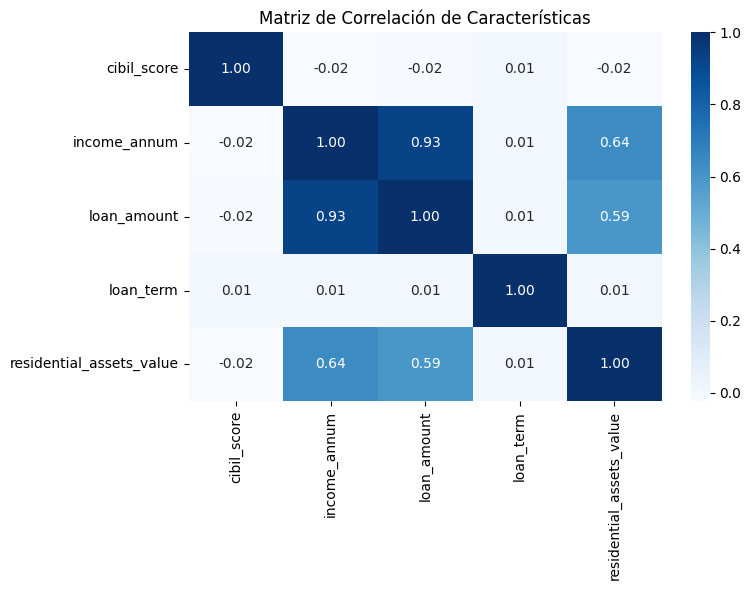

In [ ]:
# ==========================================
# 3. MATRIZ DE CORRELACIÓN Y PREPROCESAMIENTO
# ==========================================
plt.figure(figsize=(8, 6))
correlation_matrix = df[features + ['loan_term', 'residential_assets_value']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Matriz de Correlación de Características')
plt.tight_layout()
plt.show()

# División en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Transformación Polinómica (Grado 2)
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Escalado Estándar (Requerido para la convergencia del Gradiente Descendente)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Añadir columna de Bias/Intercepto (Unos)
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

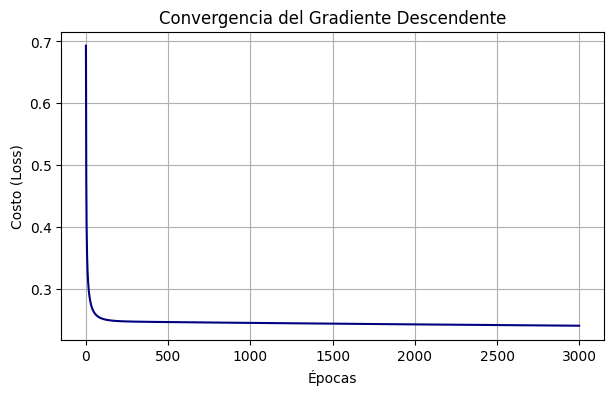

In [ ]:
# ==========================================
# 4. ALGORITMO DE GRADIENTE DESCENDENTE DESDE CERO
# ==========================================
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def fit_logistic_regression_gd(X, y, lr=0.5, epochs=3000):
    m, n = X.shape
    weights = np.zeros(n)
    cost_history = []

    for epoch in range(epochs):
        z = np.dot(X, weights)
        h = sigmoid(z)

        # Función de Costo Binary Cross-Entropy
        cost = (-1 / m) * np.sum(y * np.log(h + 1e-15) + (1 - y) * np.log(1 - h + 1e-15))
        cost_history.append(cost)

        # Gradiente
        gradient = np.dot(X.T, (h - y)) / m
        weights -= lr * gradient

    return weights, cost_history

# Entrenamiento del modelo
weights, cost_history = fit_logistic_regression_gd(X_train_b, y_train, lr=0.5, epochs=3000)

# Gráfica de convergencia del Costo
plt.figure(figsize=(7, 4))
plt.plot(cost_history, color='navy')
plt.title('Convergencia del Gradiente Descendente')
plt.xlabel('Épocas')
plt.ylabel('Costo (Loss)')
plt.grid(True)
plt.show()

Accuracy Train: 92.36%
Accuracy Test:  92.97%


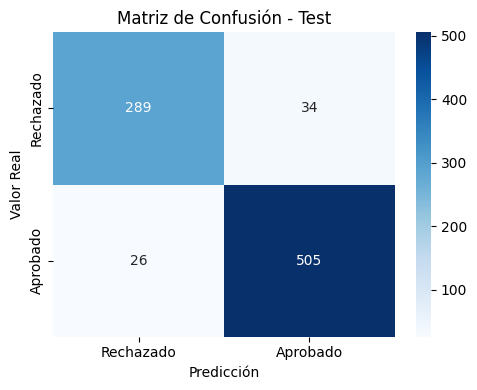

In [ ]:
# ==========================================
# 5. EVALUACIÓN Y MÉTRICAS
# ==========================================
y_pred_train = (sigmoid(np.dot(X_train_b, weights)) >= 0.5).astype(int)
y_pred_test = (sigmoid(np.dot(X_test_b, weights)) >= 0.5).astype(int)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy Train: {acc_train * 100:.2f}%")
print(f"Accuracy Test:  {acc_test * 100:.2f}%")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
plt.title('Matriz de Confusión - Test')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 6. EXPORTACIÓN DEL MODELO Y TRANSFORMADORES
# ==========================================
# Guardar transformadores y pesos aprendidos en archivos binarios
joblib.dump(poly, 'poly_features.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(weights, 'logistic_regression_weights.joblib')

print("\n Archivos exportados exitosamente:")
print(" - poly_features.joblib")
print(" - scaler.joblib")
print(" - logistic_regression_weights.joblib")


 Archivos exportados exitosamente:
 - poly_features.joblib
 - scaler.joblib
 - logistic_regression_weights.joblib


In [10]:
# ==========================================\n"
# 4. INFORMACIÓN DEL MODELO Y CONJUNTOS DE DATOS\n"
# ==========================================\n"
print(f"Grado del polinomio: {degree}")
print(f"Tamaño del conjunto de Train: {X_train.shape[0]} muestras ({X_train.shape[1]} características originales)")
print(f"Tamaño del conjunto de Test:  {X_test.shape[0]} muestras ({X_test.shape[1]} características originales)")
print(f"Características tras expansión polinómica: {X_train_poly.shape[1]}")

Grado del polinomio: 2
Tamaño del conjunto de Train: 3415 muestras (3 características originales)
Tamaño del conjunto de Test:  854 muestras (3 características originales)
Características tras expansión polinómica: 9
